# 🌸 Iris Dataset Segmentation Example

In this notebook, we demonstrate **clustering and segmentation** on the classic Iris dataset. We'll:
1. Cluster the flowers using **K-Means**
2. Profile each resulting segment
3. Interpret the groups to understand the segmentation


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

In [10]:
# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['true_species'] = iris.target
df['true_species_name'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Standardize for clustering
X_scaled = StandardScaler().fit_transform(df[iris.feature_names])

In [11]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Compare with true labels
ari = adjusted_rand_score(df['true_species'], df['cluster'])
print(f'Adjusted Rand Index (vs. true species): {ari:.3f}')

Adjusted Rand Index (vs. true species): 0.620


In [12]:
# Profile each cluster
cluster_profile = df.groupby('cluster')[iris.feature_names].mean()
display(cluster_profile)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.780851,3.095745,5.510638,1.972340
1,5.006000,3.428000,1.462000,0.246000
2,5.801887,2.673585,4.369811,1.413208


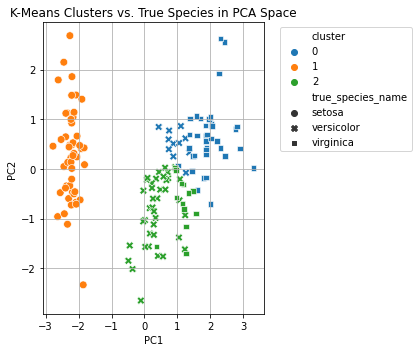

In [13]:
# Visualize clusters in PCA-reduced 2D space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster', palette='tab10', style='true_species_name', s=60)
plt.title('K-Means Clusters vs. True Species in PCA Space')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

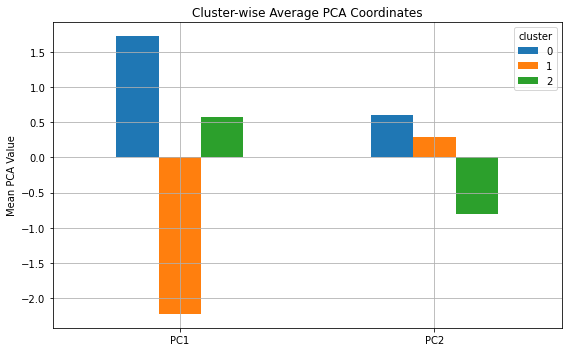

In [17]:




# Plot the means as a bar chart
pca_means.plot(kind='bar', figsize=(8, 5))

plt.title('Cluster-wise Average PCA Coordinates')
plt.ylabel('Mean PCA Value')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()


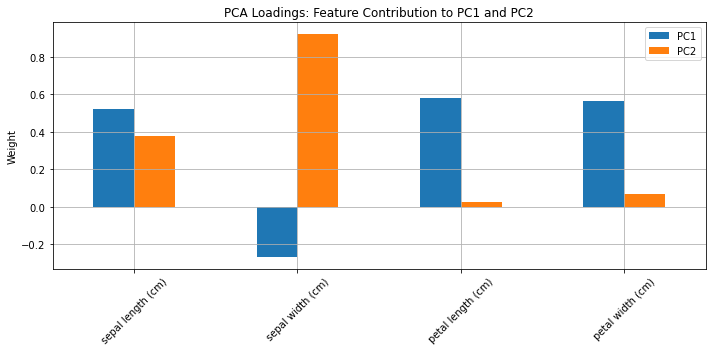

In [18]:
loading_df = pd.DataFrame(pca.components_, columns=iris.feature_names, index=['PC1', 'PC2'])

loading_df.T.plot(kind='bar', figsize=(10, 5))
plt.title('PCA Loadings: Feature Contribution to PC1 and PC2')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

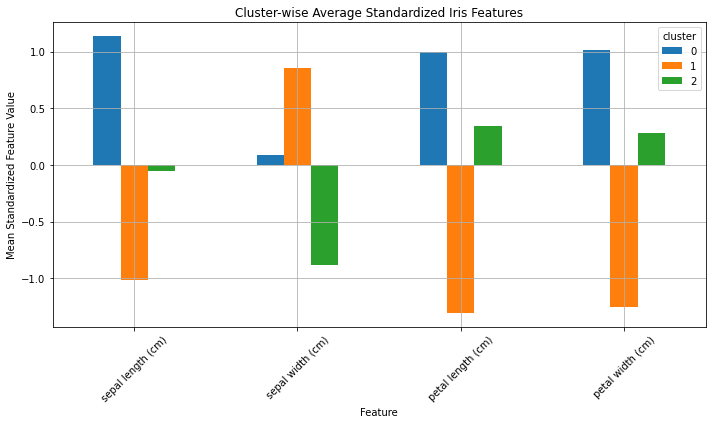

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create standardized feature DataFrame and attach cluster labels
df_std = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_std['cluster'] = df['cluster']

# Step 2: Compute cluster-wise mean of standardized features
cluster_means = df_std.groupby('cluster')[iris.feature_names].mean().T

# Step 3: Plot — each group of bars = a feature, one bar per cluster
cluster_means.plot(kind='bar', figsize=(10, 6))

plt.title('Cluster-wise Average Standardized Iris Features')
plt.ylabel('Mean Standardized Feature Value')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
